In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import pickle
import sinter
from copy import deepcopy
import scipy

import src.device as device
import src.plotting as plotter
import src.stim_dag as stim_dag

from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.TileCode import TileCode
from src.HGPCode import HGPCode
from src.SHYPSCode import SHYPSCode
from src.RadialCode import RadialCode
from src.GBCode import GBCode
from src.HypercubeCode import HypercubeCode
from src.decoders import BPOSD

In [2]:
compile_tasks = False
if compile_tasks:
    # Making codes
    codes = []
    code_types = []
    code_nkds = []
    code_data_coodes = []

    ds_surface = [3, 5, 7, 9, 11]
    for d in ds_surface:
        code = RotatedSurfaceCode(d)
        codes.append(code)
        code_types.append('Surface')
        code_nkds.append(code.compute_code_parameters())

    nkds_tile = [(288,8,12), (288, 8, 14), (288, 18, 13), (512, 18, 19)]
    for nkd in nkds_tile:
        code = TileCode.known_code(*nkd)
        codes.append(code)
        code_types.append('Tile')
        code_nkds.append(nkd)

    rs_simplex = [3,4]
    for r in rs_simplex:
        code = HGPCode.simplex_code(r)
        codes.append(code)
        code_types.append('Simplex')
        code_nkds.append(code.compute_code_parameters())

    # rs_cube = [2,3]
    # for r in rs_cube:
    #     code = HypercubeCode(r)
    #     codes.append(code)
    #     code_types.append('Hypercube')
    #     code_nkds.append(code.compute_code_parameters())

    lms = [
        (6,6),
        (12,6),
        (12,12),
    ]
    orders = [
        (([3], [1,2]), ([1, 2], [3])),
        (([3], [1, 2]), ([1, 2], [3])),
        (([3], [2, 7]), ([1, 2], [3])),
    ]
    nkds = [
        (72, 12, 6),
        (144, 12, 12),
        (288, 12, 18),
    ]
    for (l,m),(a_ord,b_ord) in zip(lms, orders):
        code = GBCode(l, m, a_ord, b_ord)
        codes.append(code)
        code_types.append('BB')

    code_nkds += nkds

    rsds_radial = [(3,8,12), (3,11,14), (4,6,12), (4,8,16), (4,11,20)]
    for r,s,d in rsds_radial:
        code = RadialCode(r,s,d)
        codes.append(code)
        code_types.append('Radial')
        code_nkds.append(code.compute_code_parameters())

    for code in codes:
        assert len(code.qubit_coords) > 0, code

    code_ids = list(zip(code_types, code_nkds))
else:
    ds_surface = [3, 5, 7, 9, 11]

In [3]:
if compile_tasks:
    hwp = device.default_hwp
    p_shs = np.geomspace(1e-3, 1e-2, 3)
    p_g = 1e-3
    T2 = 10e-3
    buffer = 3
    basis = 'X'
    schedules = dict()
    tasks = []
    for code, code_type, (n,k,d) in zip(codes, code_types, code_nkds):
        print(code_type, f'[[{n}, {k}, {d}]]...')
        xmax,ymax = 0,0
        data_coords = dict()
        for i in code.data_indices:
            x,y = code.qubit_coords[i]
            data_coords[i] = (x+buffer, y+buffer)
            xmax = max(xmax, x)
            ymax = max(ymax, y)
        dev = device.UnitCellDevice(xmax+2*buffer, ymax+2*buffer, hwp)
        
        rounds = d

        if code_type == 'Surface':
            sched = code.get_schedule(hwp, 'Z', rounds=rounds, refocus_shuttling_noise=False)
        else:
            sched = dev.compile_QEC_schedule(
                code,
                data_coords,
                code.check_cx_layers,
                rounds=rounds,
                use_highways=False,
                refocus_shuttle_noise=False,
                separate_X_Z=code_type != 'Surface',
            )
        schedules[(code_type, (n,k,d))] = sched
        
        for p_sh in p_shs:
            error_params = device.error_params(p=p_g, T2=T2, p_sh=p_sh)
            circ = sched.to_stim_circuit(code, basis, error_params, XYZ_decode=False)
            try:
                circ.detector_error_model()
            except Exception as e:
                print('FAIL', e)

            decoder='pymatching' if code_type == 'Surface' else 'bposd'
            tasks.append(sinter.Task(
                circuit=circ,
                decoder=decoder,
                json_metadata={'n':n, 'k':k, 'd':d, 'type':code_type, 'rounds':rounds, 'basis':basis, 'decoder':decoder, 'p_g':p_g, 'T2':T2, 'p_sh':p_sh},
            ))
    with open('notebooks/data/12_tasks.pkl', 'wb') as f:
        pickle.dump({
            'tasks':tasks,
        }, f)
    with open('notebooks/data/12_params.pkl', 'wb') as f:
        pickle.dump({
            'code_types':code_types,
            'code_nkds':code_nkds,
            'code_data_coodes':code_data_coodes,
            'p_shs': p_shs,
            'schedules':schedules,
        }, f)
else:
    try:
        with open('notebooks/data/12_tasks.pkl', 'rb') as f:
            data = pickle.load(f)
            tasks = data['tasks']
    except FileNotFoundError:
        print('Could not find task file. Setting tasks=None.')
        tasks = None
    with open('notebooks/data/12_params.pkl', 'rb') as f:
        data = pickle.load(f)
        code_types = data['code_types']
        code_nkds = data['code_nkds']
        code_data_coodes = data['code_data_coodes']
        p_shs = data['p_shs']
        schedules = data['schedules']

In [4]:
stats = sinter.read_stats_from_csv_files('notebooks/data/12_results_TMP')
# with open('notebooks/data/10_results_norefoc.pkl', 'rb') as f:
#     stats = pickle.load(f)
#     stats = [s for s in stats if 'p' in s.json_metadata]

In [5]:
code_ids = list(zip(code_types, code_nkds))

In [6]:
def logical_fit(p, a, b, d):
    return a*(p/b)**d

data = {code_id: np.full(len(p_shs), np.nan) for code_id in code_ids}

for i,(code_type,(n,k,d)) in enumerate(code_ids):
    for stat in stats:
        if stat.shots == 0:
            continue
        jmd = stat.json_metadata
        if (jmd['type'], jmd['n'], jmd['k'], jmd['d']) == (code_type, n, k, d):
            p = jmd['p_sh']
            p_idx = np.where(p_shs == p)[0][0]
            ler = stat.errors / stat.shots
            ler = sinter.shot_error_rate_to_piece_error_rate(ler, pieces=d, values=k)
            data[(code_type,(n,k,d))][p_idx] = ler

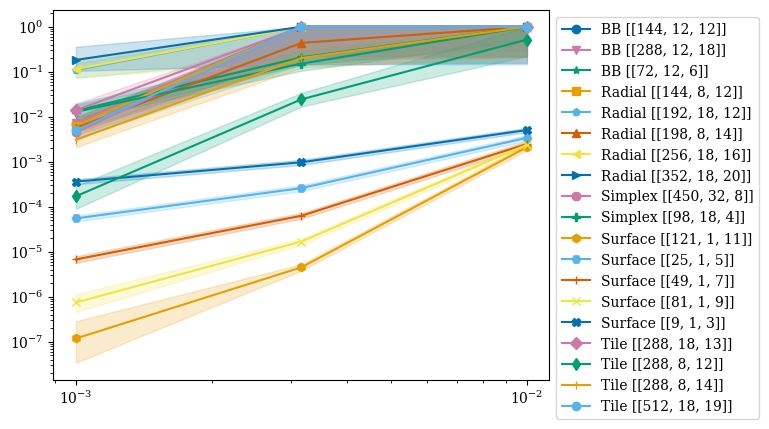

In [7]:
fig,ax = plt.subplots()
xs_test = np.geomspace(5e-4, 1e-3, 10)
xs_test_surface = np.geomspace(5e-4, 4e-3, 10)
# for fp,code_type in zip(fit_params, code_types):
#     print(fp)
#     if code_type == 'Surface':
#         plt.plot(xs_test_surface, logical_fit(xs_test_surface, *fp), 'k--', alpha=0.2)
#     else:
#         plt.plot(xs_test, logical_fit(xs_test, *fp), 'k--', alpha=0.2)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p_sh'],
    group_func=lambda s: f"{s.json_metadata['type']} [[{s.json_metadata['n']}, {s.json_metadata['k']}, {s.json_metadata['d']}]]",
    failure_units_per_shot_func=lambda s: s.json_metadata['d'],
    failure_values_func=lambda s: s.json_metadata['k'],
)

plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.loglog()
plt.show()

In [8]:
f'{1/3:2g}'

'0.333333'

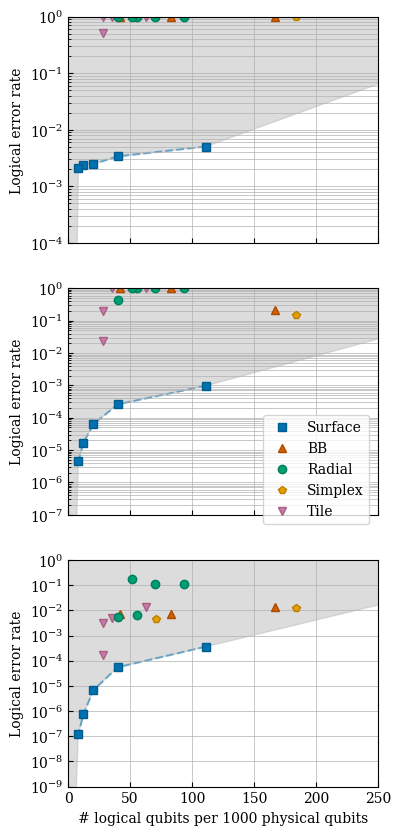

In [9]:
from adjustText import adjust_text

label_all = False
label_codes = [
    ('Simplex', (98,18,4)),
    ('BB', (72,12,6)),
    ('BB', (144,12,12)),
    ('BB', (288,12,18)),
    # ('Radial', (90,8,10)),
    ('Radial', (198,8,14)),
]

markerdict = {
    'Surface':'s',
    'BB':'^',
    'Radial':'o',
    'Simplex':'p',
    'Tile':'v'
}
colordict = {
    'Surface':'C0',
    'BB':'C5',
    'Radial':'C2',
    'Simplex':'C3',
    'Tile':'C1'
}

ps_display = [
    r'10^{-3}',
    r'3 \times 10^{-4}',
    r'10^{-4}',
]

fig,ax = plt.subplots(3,1,figsize=(4,10))
fig.subplots_adjust(hspace=0.2)
for j,p_tgt in enumerate(reversed(p_shs)):
    p_sh_tgt = p_tgt
    p_sh_i = len(p_shs)-j-1

    points = [(np.nan, np.nan) for _ in code_ids]
    texts = []
    for i,(code_type, (n,k,d)) in enumerate(code_ids):
        ler_proj = data[(code_type, (n,k,d))][p_sh_i]
        enc_rate = k / n
        points[i] = (enc_rate*1000, ler_proj)
        ax[j].plot(*points[i], marker=markerdict[code_type], color=colordict[code_type], markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2))
        # if label_all or (code_type, (n,k,d)) in label_codes:
        #     texts.append(ax[j].text(*points[i], f'[[{n}, {k}, {d}]]', fontsize=9, ha='left', va='top'))
    xs_surface = []
    ys_surface = []
    for d in ds_surface:
        pt = points[code_ids.index(('Surface', (d**2,1,d)))]
        xs_surface.append(pt[0])
        ys_surface.append(pt[1])
    ax[j].plot(xs_surface, ys_surface, 'C0--', alpha=0.5, zorder=0.2)
    ax[j].set_yscale('log')

    ax[j].set_xlim(0, 250)
    ax[j].set_ylim(top=1)
    xlim = ax[j].get_xlim()
    ylim = ax[j].get_ylim()

    xs_surface = np.array([-10] + xs_surface + [400])
    ys_surface = np.array([1e-30] + ys_surface + [1])
    sort_idx = np.argsort(xs_surface)
    ax[j].fill_between(xs_surface[sort_idx], ys_surface[sort_idx], [1]*len(ys_surface), color='#BBBBBB', zorder=0, alpha=0.5)

    ax[j].set_xlim(*xlim)
    ax[j].set_ylim(*ylim)

    for (code_type, marker) in markerdict.items():
        ax[j].plot([], [], color=colordict[code_type], marker=marker, linestyle='none', markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2), label=code_type)
    if j == 1:
        ax[j].legend(bbox_to_anchor=(0.8,0.2), loc='center')

    
    # ax[j].set_title(r'$(p,T_2,p_\text{sh})=(' + ps_display[j] + f', {T2_tgt*1e3:.2g}ms, ' + ps_display[j] + r')$')
    if j == 2:
        ax[j].set_xlabel('# logical qubits per 1000 physical qubits')
    else:
        ax[j].set_xticklabels([])
    ax[j].set_ylabel('Logical error rate')
    # ax[j].ylim(1e-18, 1e-2)
    ax[j].set_yticks(ax[j].get_yticks(), minor=[])
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray'),
        # force_text=(1, 1),
        force_static=(1, 1),
        expand=(1.2, 3),
        prevent_crossings=True,
        add_objects=ax[j].collections,
        ax=ax[j],
    )
    ax[j].grid(which='both', linewidth=0.5, zorder=0.1)
    ax[j].tick_params(direction='in', which='both')
    ax[j].set_ylim(top=1)
# plt.savefig('notebooks/fig/10_encoding_rate.pdf', bbox_inches='tight')
# plt.savefig('notebooks/fig/10_encoding_rate.svg', bbox_inches='tight')
plt.show()

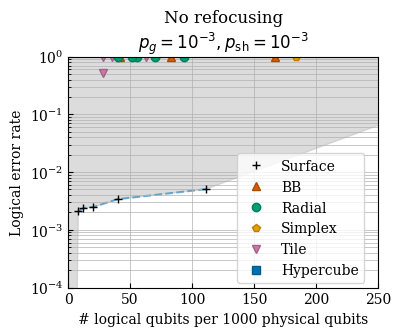

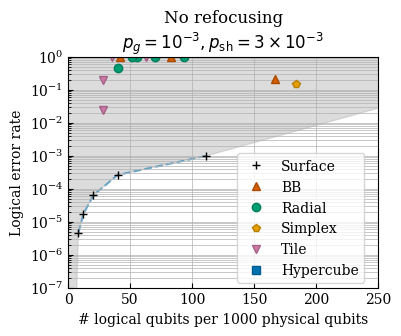

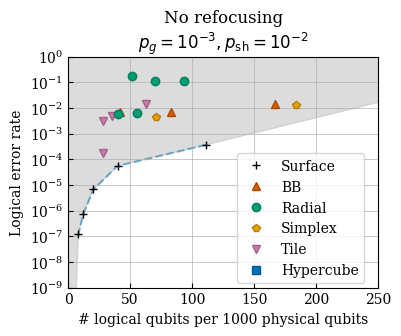

: 

In [ ]:
from adjustText import adjust_text

label_all = False
label_codes = [
    ('Simplex', (98,18,4)),
    ('BB', (72,12,6)),
    ('BB', (144,12,12)),
    ('BB', (288,12,18)),
    # ('Radial', (90,8,10)),
    ('Radial', (198,8,14)),
]

markerdict = {
    'Surface':'+',
    'BB':'^',
    'Radial':'o',
    'Simplex':'p',
    'Tile':'v',
    'Hypercube':'s',
}
colordict = {
    'Surface':'k',
    'BB':'C5',
    'Radial':'C2',
    'Simplex':'C3',
    'Tile':'C1',
    'Hypercube':'C0'
}

ps_display = [
    r'10^{-3}',
    r'3 \times 10^{-3}',
    r'10^{-2}',
]


for j,p_tgt in enumerate(reversed(p_shs)):
    p_sh_tgt = p_tgt
    p_sh_i = len(p_shs)-j-1
    fig,ax = plt.subplots(figsize=(4,3))

    points = [(np.nan, np.nan) for _ in code_ids]
    texts = []
    for i,(code_type, (n,k,d)) in enumerate(code_ids):
        ler_proj = data[(code_type, (n,k,d))][p_sh_i]
        enc_rate = k / n
        points[i] = (enc_rate*1000, ler_proj)
        ax.plot(*points[i], marker=markerdict[code_type], color=colordict[code_type], markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2))
        # if label_all or (code_type, (n,k,d)) in label_codes:
        #     texts.append(ax.text(*points[i], f'[[{n}, {k}, {d}]]', fontsize=9, ha='left', va='top'))
    xs_surface = []
    ys_surface = []
    for d in ds_surface:
        pt = points[code_ids.index(('Surface', (d**2,1,d)))]
        xs_surface.append(pt[0])
        ys_surface.append(pt[1])
    ax.plot(xs_surface, ys_surface, 'C0--', alpha=0.5, zorder=0.2)
    ax.set_yscale('log')

    ax.set_xlim(0, 250)
    ax.set_ylim(top=1)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xs_surface = np.array([-10] + xs_surface + [400])
    ys_surface = np.array([1e-30] + ys_surface + [1])
    sort_idx = np.argsort(xs_surface)
    ax.fill_between(xs_surface[sort_idx], ys_surface[sort_idx], [1]*len(ys_surface), color='#BBBBBB', zorder=0, alpha=0.5)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    for (code_type, marker) in markerdict.items():
        ax.plot([], [], color=colordict[code_type], marker=marker, linestyle='none', markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2), label=code_type)

    ax.legend(bbox_to_anchor=(0.75,0.3), loc='center')
    
    ax.set_title('No refocusing\n' + r'$p_g=10^{-3}, p_\text{sh}=' + ps_display[j] + r'$')
    ax.set_xlabel('# logical qubits per 1000 physical qubits')

    ax.set_ylabel('Logical error rate')
    # ax.ylim(1e-18, 1e-2)
    ax.set_yticks(ax.get_yticks(), minor=[])
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray'),
        # force_text=(1, 1),
        force_static=(1, 1),
        expand=(1.2, 3),
        prevent_crossings=True,
        add_objects=ax.collections,
        ax=ax,
    )
    ax.grid(which='both', linewidth=0.5, zorder=0.1)
    ax.tick_params(direction='in', which='both')
    ax.set_ylim(top=1)
    plt.savefig(f'notebooks/fig/12_encoding_rate_{j}.pdf', bbox_inches='tight')
    # plt.savefig('notebooks/fig/10_encoding_rate.svg', bbox_inches='tight')
    plt.show()